In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


In [2]:
# With millions of songs available on platforms like Amazon, 
# manually categorizing tracks into genres is impractical. 
# The goal of this project is to automatically group similar songs based on their audio characteristics using clustering techniques. 
# By analyzing patterns in features such as tempo, energy, danceability, and more, 
# learners will develop a model that organizes songs into meaningful clusters, 
# potentially representing different musical genres or moods—without any prior labels.

In [3]:
df = pd.read_csv('single_genre_artists.csv')

In [4]:
pd.set_option('display.max_columns', None)
df

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.1840,4,-13.757,1,0.0512,0.993,0.000016,0.3250,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.1800,10,-15.375,1,0.0670,0.989,0.000000,0.1280,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.2060,0,-15.514,1,0.0592,0.995,0.000000,0.4180,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.4670,9,-12.393,0,0.1650,0.991,0.000000,0.2190,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.2980,9,-13.806,1,0.1380,0.991,0.000000,0.3730,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95832,44r4zta6P9flkhKaVnbsvG,Freaks,70,174800,0,14Y3trk7LaslSFTk1G35rx,2019-02-25,0.674,0.5680,1,-6.356,1,0.0408,0.116,0.000000,0.1650,0.640,166.107,4,16057.0,['alt z'],Jordan Clarke,56
95833,0MmaEacabpK8Yp3Mdeo5uY,下雨天,50,265846,0,5VGgFE9nPgMfEnYiPT5J2B,2020-02-25,0.528,0.6730,4,-3.639,1,0.0314,0.143,0.000000,0.0989,0.297,130.066,4,929.0,['chinese viral pop'],芝麻,36
95834,1dKxf4Ht2SsKLyXfSDJAgy,The Cutest Puppy,67,82500,0,7vgGpuiXdNlCmc994PlMlz,2020-10-30,0.609,0.0172,8,-28.573,1,0.1180,0.996,0.973000,0.1080,0.890,68.619,4,23.0,['instrumental lullaby'],Laureen Conrad,52
95835,0SjsIzJkZfDU7wlcdklEFR,John Brown's Song,66,185250,0,4MxqhahGRT4BPz1PilXGeu,2020-03-20,0.562,0.0331,1,-25.551,1,0.1030,0.996,0.961000,0.1110,0.386,63.696,3,91.0,['instrumental lullaby'],Gregory Oberle,55


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  object 
 1   name_song           95837 non-null  object 
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  int64  
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  object 
 6   release_date        95837 non-null  object 
 7   danceability        95837 non-null  float64
 8   energy              95837 non-null  float64
 9   key                 95837 non-null  int64  
 10  loudness            95837 non-null  float64
 11  mode                95837 non-null  int64  
 12  speechiness         95837 non-null  float64
 13  acousticness        95837 non-null  float64
 14  instrumentalness    95837 non-null  float64
 15  liveness            95837 non-null  float64
 16  vale

In [6]:
df.duplicated().sum()
# there is no dublicates in the dataset

0

In [7]:
df.isna().sum() 
# there is no missing values in the dataset

id_songs              0
name_song             0
popularity_songs      0
duration_ms           0
explicit              0
id_artists            0
release_date          0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
time_signature        0
followers             0
genres                0
name_artists          0
popularity_artists    0
dtype: int64

In [8]:
df.columns.tolist()

['id_songs',
 'name_song',
 'popularity_songs',
 'duration_ms',
 'explicit',
 'id_artists',
 'release_date',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature',
 'followers',
 'genres',
 'name_artists',
 'popularity_artists']

In [9]:
# dropping unecessary columns as these were not needed for clustering
# df.drop(columns=['id_songs', 'id_artists', 'name_song', 'name_artists', 
#                  'popularity_songs', 'popularity_artists', 'followers'], inplace=True)
# just dropping the ID_songs and ID_artists columns
df.drop(columns=['id_songs', 'id_artists'], inplace=True)

In [10]:
df.head()

,name_song,popularity_songs,duration_ms,explicit,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,La Java,0,161427,0,1922,0.563,0.184,4,-13.757,1,0.0512,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,En Douce,0,223440,0,1922,0.427,0.180,10,-15.375,1,0.0670,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,J'en Ai Marre,0,208267,0,1922,0.511,0.206,0,-15.514,1,0.0592,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,Ils n'ont pas ca,0,161933,0,1924,0.676,0.467,9,-12.393,0,0.1650,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,La belote,0,167973,0,1924,0.650,0.298,9,-13.806,1,0.1380,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22


In [11]:
pd.set_option('display.max_rows', None)
print(df['genres'].unique())

["['vintage chanson']" "['new orleans jazz']" "['harlem renaissance']" ...
 "['chinese classical performance']" "['chinese new year']"
 "['singaporean indie']"]


In [12]:
pd.set_option('display.max_rows', None)
df['genres'].value_counts()

genres
['hoerspiel']                                                                                                                                                                                                                                          8027
['kleine hoerspiel']                                                                                                                                                                                                                                   2081
[]                                                                                                                                                                                                                                                     1876
['classic israeli pop']                                                                                                                                                                                                                      

In [13]:
# We replace the brackets and quotes with "nothing" (empty string)
df['genres'] = df['genres'].str.replace(r"[\[\]']", "", regex=True)



In [14]:
# Let's check our work!
print(df['genres'].value_counts())

genres
hoerspiel                                                                                                                                                                                                              8027
kleine hoerspiel                                                                                                                                                                                                       2081
                                                                                                                                                                                                                       1876
classic israeli pop                                                                                                                                                                                                    1180
vintage taiwan pop                                                                                               

In [15]:
# after cleaning the genres column, 
# checking for any missing values thought there should be none when the box brackets are removed
df['genres'].isna().sum()

0

In [16]:
df.head()

,name_song,popularity_songs,duration_ms,explicit,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,La Java,0,161427,0,1922,0.563,0.184,4,-13.757,1,0.0512,0.993,0.000016,0.325,0.654,133.088,3,5078.0,vintage chanson,Mistinguett,22
1,En Douce,0,223440,0,1922,0.427,0.180,10,-15.375,1,0.0670,0.989,0.000000,0.128,0.431,78.459,3,5078.0,vintage chanson,Mistinguett,22
2,J'en Ai Marre,0,208267,0,1922,0.511,0.206,0,-15.514,1,0.0592,0.995,0.000000,0.418,0.481,70.443,4,5078.0,vintage chanson,Mistinguett,22
3,Ils n'ont pas ca,0,161933,0,1924,0.676,0.467,9,-12.393,0,0.1650,0.991,0.000000,0.219,0.726,129.775,4,5078.0,vintage chanson,Mistinguett,22
4,La belote,0,167973,0,1924,0.650,0.298,9,-13.806,1,0.1380,0.991,0.000000,0.373,0.844,75.950,4,5078.0,vintage chanson,Mistinguett,22


In [17]:
# 1. First, tell pandas to read the dates correctly (handling mixed formats)
df['release_date'] = pd.to_datetime(df['release_date'], format='mixed', errors='coerce')

# 2. Now, extract ONLY the year part and overwrite the old column
df['release_date'] = df['release_date'].dt.year

print(df['release_date'].head())

0    1922
1    1922
2    1922
3    1924
4    1924
Name: release_date, dtype: int32


In [18]:
# Feature Selection for Clustering

In [19]:
# selecting columns for clustering


features = [
    'danceability','energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 
    'liveness', 'duration_ms','valence', 'tempo'
    ]
# creating subset X
x=df[features].copy()

# scaling the data using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

In [20]:
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
display(X_scaled_df.head())

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,duration_ms,valence,tempo
0,-0.153476,-1.511128,-0.757909,-0.427109,1.616187,-0.353338,0.538584,-0.401735,0.321287,0.515005
1,-1.028518,-1.528056,-1.098629,-0.369741,1.604081,-0.353405,-0.521537,0.124906,-0.577455,-1.294487
2,-0.488051,-1.418027,-1.127899,-0.398062,1.622240,-0.353405,1.039046,-0.003949,-0.375943,-1.560003
3,0.573581,-0.313510,-0.470677,-0.013914,1.610134,-0.353405,-0.031836,-0.397437,0.611464,0.405268
4,0.406294,-1.028695,-0.768227,-0.111948,1.610134,-0.353405,0.796887,-0.346143,1.087031,-1.377593


In [21]:
# Principal Componenet Analysis (PCA) 
# unsupervised learning technique used for dimensionality reduction
# Why didn't we use t-SNE? It is very slow on large datasets (like this one is 90k+ ). 
# PCA takes seconds; t-SNE might take an hour.



pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)


# PCA 2d coordinates ready

In [22]:
print(X_scaled.shape)
print(pca_data.shape)

(95837, 10)
(95837, 2)


In [23]:
# Elbow Method to find the optimal number of clusters
# K-Means is used for its simplicity and efficiency on large datasets,
# assuming roughly spherical clusters in the feature space.


c:\Users\FAROOQUE\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\FAROOQUE\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\FAROOQUE\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\FAROOQUE\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\FAROOQUE\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _w

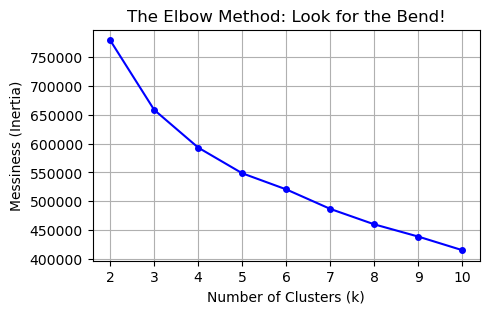

In [24]:
# finding K

inertia =  []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plotting the Elbow Curve
plt.figure(figsize=(5, 3))
plt.plot(K_range, inertia, 'bo-', markersize=4) # Blue line with dots
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Messiness (Inertia)')
plt.title('The Elbow Method: Look for the Bend!')
plt.grid(True)
plt.show()

In [25]:
# From the elbow plot, the inertia curve shows a clear bend at **k = 5**.
# Beyond this point, the reduction in inertia diminishes, indicating marginal
# improvement from adding more clusters. Therefore, k = 5 was selected as the
# optimal number of clusters.


In [26]:
# clustering with K-means


k_final = 5
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df['cluster_label'] = kmeans_final.fit_predict(X_scaled)

print("✅ Success! Every song has been assigned to a Team (0-4).")

✅ Success! Every song has been assigned to a Team (0-4).


In [27]:
# checking Cluster sizes
print(df['cluster_label'].value_counts())

cluster_label
0    30373
3    24584
4    21080
2    12273
1     7527
Name: count, dtype: int64


In [28]:
# silhouette score
from sklearn.metrics import silhouette_score
sil = silhouette_score(X_scaled, df['cluster_label'], sample_size=10000, random_state=42)
print(sil)

0.1861979981815724


In [29]:
# davis-bouldin score
from sklearn.metrics import davies_bouldin_score

dbs = davies_bouldin_score(X_scaled, df['cluster_label'])
print(dbs)

1.6887803783812507


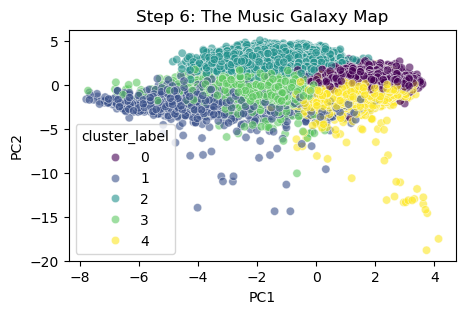

In [30]:
# Scatter plot 
# using PCA to draw a map

pca_df = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
pca_df['cluster_label'] = df['cluster_label']

plt.figure(figsize=(5, 3))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='cluster_label', 
    data=pca_df, 
    palette='viridis', 
    alpha=0.6
)
plt.title('Step 6: The Music Galaxy Map')
plt.show()

In [31]:
# interpretation (Decoding and Saving)

features_to_check = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness']
cluster_means = df.groupby('cluster_label')[features_to_check].mean()
cluster_means

,danceability,energy,loudness,speechiness,acousticness,instrumentalness
cluster_label,,,,,,
0,0.706962,0.671949,-7.986034,0.078149,0.309603,0.021395
1,0.484072,0.400033,-14.207328,0.059369,0.668444,0.817177
2,0.664406,0.466487,-13.387732,0.838939,0.586096,0.000879
3,0.503925,0.313460,-12.634777,0.062285,0.743712,0.018421
4,0.502056,0.711780,-7.072090,0.072693,0.193385,0.028849


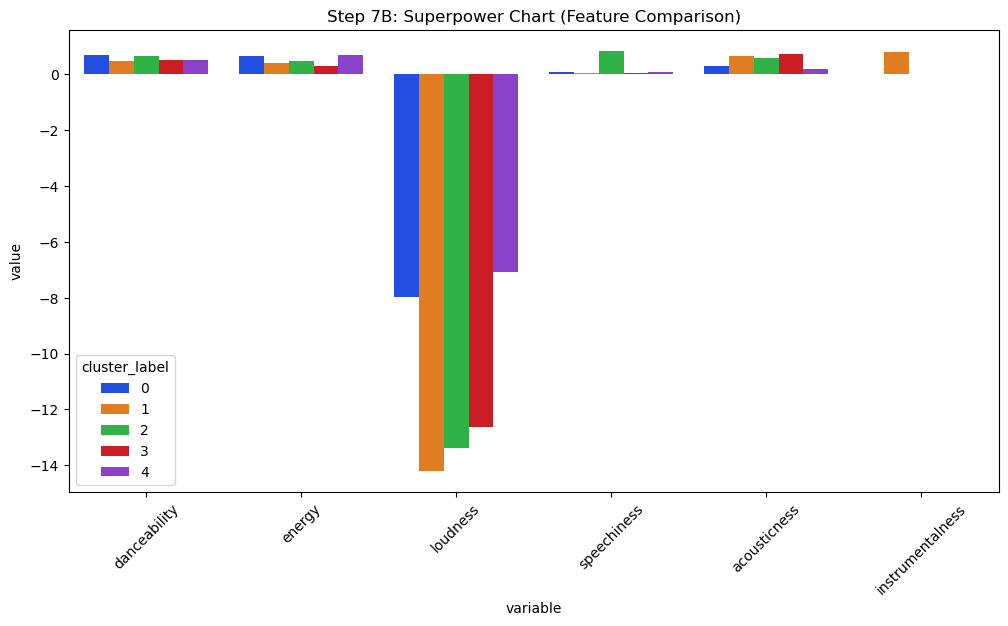

In [32]:
plot_data = cluster_means.reset_index().melt(id_vars='cluster_label')

plt.figure(figsize=(12, 6))
sns.barplot(x='variable', y='value', hue='cluster_label', data=plot_data, palette='bright')
plt.title('Step 7B: Superpower Chart (Feature Comparison)')
plt.xticks(rotation=45)
plt.show()

In [33]:
# saving the clustered data
df.to_csv('Final_Amazon_Music_Project.csv', index=False)

In [35]:
new_data = pd.read_csv('Final_Amazon_Music_Project.csv')
display(new_data.head())
print(new_data.shape)
print(new_data.columns.tolist())

,name_song,popularity_songs,duration_ms,explicit,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists,cluster_label
0,La Java,0,161427,0,1922,0.563,0.184,4,-13.757,1,0.0512,0.993,0.000016,0.325,0.654,133.088,3,5078.0,vintage chanson,Mistinguett,22,3
1,En Douce,0,223440,0,1922,0.427,0.180,10,-15.375,1,0.0670,0.989,0.000000,0.128,0.431,78.459,3,5078.0,vintage chanson,Mistinguett,22,3
2,J'en Ai Marre,0,208267,0,1922,0.511,0.206,0,-15.514,1,0.0592,0.995,0.000000,0.418,0.481,70.443,4,5078.0,vintage chanson,Mistinguett,22,3
3,Ils n'ont pas ca,0,161933,0,1924,0.676,0.467,9,-12.393,0,0.1650,0.991,0.000000,0.219,0.726,129.775,4,5078.0,vintage chanson,Mistinguett,22,3
4,La belote,0,167973,0,1924,0.650,0.298,9,-13.806,1,0.1380,0.991,0.000000,0.373,0.844,75.950,4,5078.0,vintage chanson,Mistinguett,22,3


(95837, 22)
['name_song', 'popularity_songs', 'duration_ms', 'explicit', 'release_date', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'followers', 'genres', 'name_artists', 'popularity_artists', 'cluster_label']
